# Deep Learning Project 3: Telecom Customer Churn Prediction
## Advanced Training, Optimization & Regularization with TensorFlow/Keras

### New Problem Statement
A telecom company wants to predict whether a customer will leave its services.

**Target:** `Churn`
- Yes → customer leaves
- No → customer stays

### Next Deep Learning Syllabus
1. Deep Learning preprocessing
2. Train/Validation/Test strategy
3. Weight initialization
4. SGD, Momentum, RMSprop and Adam
5. Learning rate
6. Batch size and epochs
7. L1/L2 regularization
8. Dropout
9. Batch Normalization
10. Early Stopping
11. Learning-rate scheduling
12. Class imbalance and class weights
13. Threshold tuning
14. ROC-AUC and Precision-Recall
15. Hyperparameter experiments
16. Model saving/loading

**Workflow:** Business Problem → EDA → Preprocessing → Neural Network → Training → Optimization → Evaluation → Improvement

## Dataset
Use **IBM Telco Customer Churn**. Download the CSV and keep it beside this notebook.

Expected filename:
`WA_Fn-UseC_-Telco-Customer-Churn.csv`

The dataset contains customer demographics, services, tenure, contract, billing information and churn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1_l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(42)
tf.keras.utils.set_random_seed(42)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## 1. Load Data
Change `DATA_PATH` if you run the notebook from another location.

In [2]:
# DATA_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
# df = pd.read_csv(DATA_PATH)
# display(df.head())
# print("Shape:", df.shape)

In [3]:
import pandas as pd

DATA_PATH = r"D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\2.Telecom-Customer-Churn-Prediction\WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)

display(df.head())

print("Shape:", df.shape)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Shape: (7043, 21)


## 2. Data Understanding
Check data types, missing values and target balance. Neural networks require numeric input, so text categories will be encoded later.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Churn distribution:


Churn
No     5174
Yes    1869
Name: count, dtype: int64

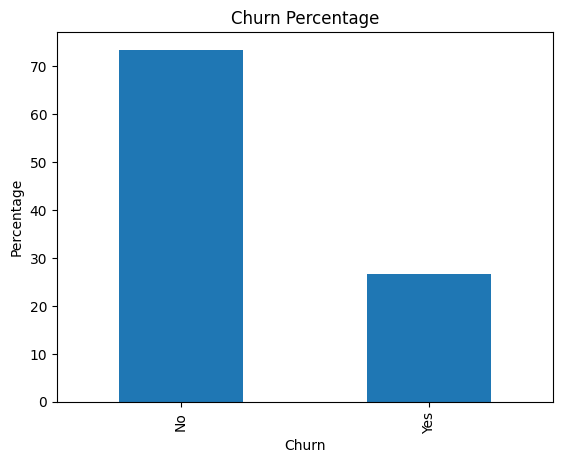

In [4]:
df.info()
print("\nMissing values:")
display(df.isnull().sum())
print("\nChurn distribution:")
display(df['Churn'].value_counts())
(df['Churn'].value_counts(normalize=True)*100).plot(kind='bar')
plt.title("Churn Percentage")
plt.ylabel("Percentage")
plt.show()

## 3. Scenario-Based Analysis
Ask business questions before modeling:
- Do short-tenure customers churn more?
- Does contract type affect churn?
- Do monthly charges differ between churners and non-churners?

In [5]:
temp=df.copy()
temp['Churn_binary']=temp['Churn'].map({'No':0,'Yes':1})
display(temp.groupby('Churn')[['tenure','MonthlyCharges']].mean().round(2))
display(pd.crosstab(temp['Contract'],temp['Churn'],normalize='index').round(3))
display(pd.crosstab(temp['InternetService'],temp['Churn'],normalize='index').round(3))

,tenure,MonthlyCharges
Churn,,
No,37.57,61.27
Yes,17.98,74.44


Churn,No,Yes
Contract,,
Month-to-month,0.573,0.427
One year,0.887,0.113
Two year,0.972,0.028


Churn,No,Yes
InternetService,,
DSL,0.810,0.190
Fiber optic,0.581,0.419
No,0.926,0.074


## 4. Clean `TotalCharges`
This column can be text even though it represents a numeric amount. Convert invalid values to missing values and fill them with the median.

In [6]:
df_model=df.copy()
df_model['TotalCharges']=pd.to_numeric(df_model['TotalCharges'],errors='coerce')
print("Missing after conversion:",df_model['TotalCharges'].isnull().sum())
df_model['TotalCharges']=df_model['TotalCharges'].fillna(df_model['TotalCharges'].median())

Missing after conversion: 11


## 5. Remove Identifier and Encode Target
`customerID` identifies a customer but usually does not represent a useful general pattern.

Target:
- No = 0
- Yes = 1

In [7]:
df_model=df_model.drop(columns=['customerID'])
df_model['Churn']=df_model['Churn'].map({'No':0,'Yes':1})
X_raw=df_model.drop(columns=['Churn'])
y=df_model['Churn']

## 6. One-Hot Encoding
Categorical columns are converted into numeric binary columns so Keras can process them.

In [8]:
X=pd.get_dummies(X_raw,drop_first=True,dtype=int)
print("Encoded shape:",X.shape)
display(X.head())

Encoded shape: (7043, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


## 7. Train / Validation / Test Split
- Training: learns weights and biases
- Validation: monitors model choices and overfitting
- Test: final unseen evaluation

In [9]:
X_train_full,X_test,y_train_full,y_test=train_test_split(
    X,y,test_size=0.15,random_state=42,stratify=y)

X_train,X_val,y_train,y_val=train_test_split(
    X_train_full,y_train_full,test_size=0.1765,random_state=42,stratify=y_train_full)

print("Train:",X_train.shape,"Validation:",X_val.shape,"Test:",X_test.shape)

Train: (4929, 30) Validation: (1057, 30) Test: (1057, 30)


## 8. Feature Scaling
Standardization makes features comparable for gradient-based optimization.

Important: fit the scaler only on training data to prevent data leakage.

In [10]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_val_scaled=scaler.transform(X_val)
X_test_scaled=scaler.transform(X_test)
n_features=X_train_scaled.shape[1]
print("Input features:",n_features)

Input features: 30


## 9. Build Baseline Neural Network
Architecture:

Input → Dense(32, ReLU) → Dense(16, ReLU) → Dense(1, Sigmoid)

`he_normal` initialization is commonly used with ReLU.
Sigmoid produces a churn probability between 0 and 1.

In [11]:
def build_baseline():
    model=Sequential([
        Input(shape=(n_features,)),
        Dense(32,activation='relu',kernel_initializer='he_normal'),
        Dense(16,activation='relu',kernel_initializer='he_normal'),
        Dense(1,activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy',tf.keras.metrics.AUC(name='auc')]
    )
    return model

baseline=build_baseline()
baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

## 10. Training Process
For every batch:
1. Forward pass
2. Prediction
3. Loss calculation
4. Backpropagation
5. Gradient calculation
6. Optimizer updates weights

An **epoch** is one complete pass through the training dataset.
A **batch** is the number of samples processed before one update.

In [12]:
history=baseline.fit(
    X_train_scaled,y_train,
    validation_data=(X_val_scaled,y_val),
    epochs=50,batch_size=32,verbose=1
)

Epoch 1/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7363 - auc: 0.7471 - loss: 0.5049 - val_accuracy: 0.7805 - val_auc: 0.7987 - val_loss: 0.4635
Epoch 2/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7856 - auc: 0.8241 - loss: 0.4385 - val_accuracy: 0.7890 - val_auc: 0.8179 - val_loss: 0.4469
Epoch 3/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7955 - auc: 0.8377 - loss: 0.4243 - val_accuracy: 0.7909 - val_auc: 0.8234 - val_loss: 0.4424
Epoch 4/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8010 - auc: 0.8440 - loss: 0.4174 - val_accuracy: 0.7938 - val_auc: 0.8246 - val_loss: 0.4412
Epoch 5/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8028 - auc: 0.8480 - loss: 0.4128 - val_accuracy: 0.7900 - val_auc: 0.8249 - val_loss: 0.4410
Epoch 6/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8052 - auc: 0.8511 - loss: 0.4093 - val_accuracy: 0.7871 - val_auc: 0.8249 - val_loss: 0.4414
Epoch 7/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 

## 11. Training Curves
If training improves while validation gets worse, overfitting may be occurring.

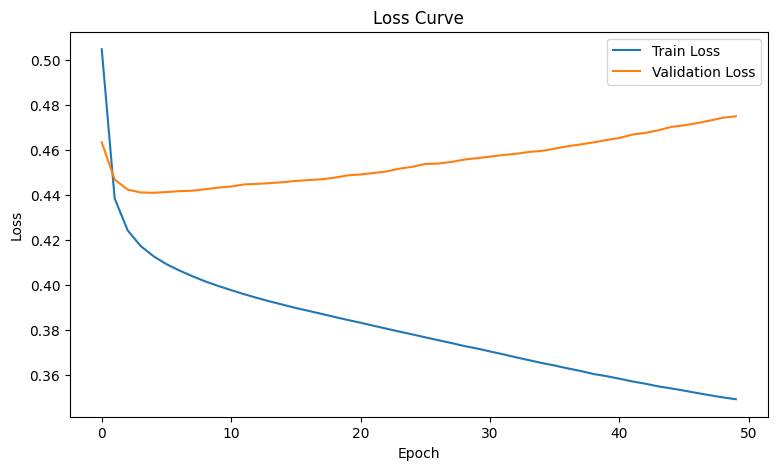

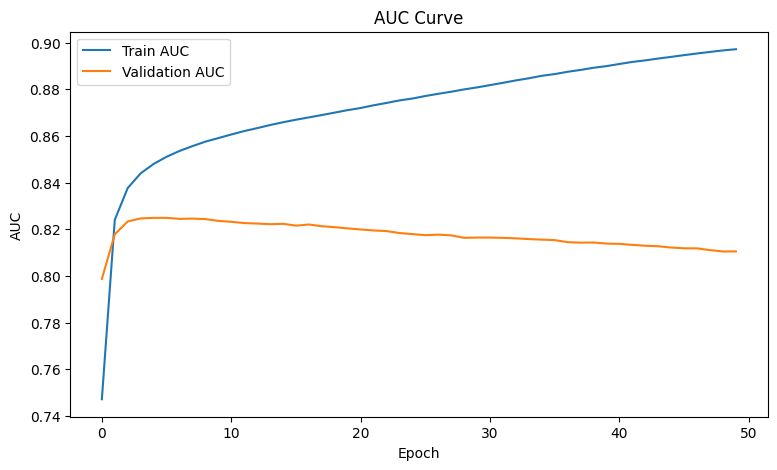

In [13]:
plt.figure(figsize=(9,5))
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()

plt.figure(figsize=(9,5))
plt.plot(history.history['auc'],label='Train AUC')
plt.plot(history.history['val_auc'],label='Validation AUC')
plt.title("AUC Curve")
plt.xlabel("Epoch"); plt.ylabel("AUC"); plt.legend(); plt.show()

## 12. Optimizer Comparison
- SGD: basic gradient descent
- SGD + Momentum: uses previous direction
- RMSprop: adaptive gradient scaling
- Adam: adaptive learning rate + momentum-like behavior

In [14]:
def optimizer_score(optimizer):
    m=Sequential([Input(shape=(n_features,)),Dense(32,activation='relu'),
                  Dense(16,activation='relu'),Dense(1,activation='sigmoid')])
    m.compile(optimizer=optimizer,loss='binary_crossentropy',
              metrics=[tf.keras.metrics.AUC(name='auc')])
    h=m.fit(X_train_scaled,y_train,validation_data=(X_val_scaled,y_val),
            epochs=20,batch_size=32,verbose=0)
    return max(h.history['val_auc'])

opts={'Adam':Adam(0.001),'SGD':SGD(0.01),
      'SGD Momentum':SGD(0.01,momentum=0.9),'RMSprop':RMSprop(0.001)}
scores={name:optimizer_score(opt) for name,opt in opts.items()}
display(pd.Series(scores,name='Best Validation AUC').sort_values(ascending=False))

SGD Momentum    0.827379
RMSprop         0.823479
Adam            0.821255
SGD             0.815754
Name: Best Validation AUC, dtype: float64

## 13. Learning Rate Experiment
- Too high: unstable updates
- Too low: very slow learning
- Appropriate: stable convergence

In [15]:
lr_results={}
for lr in [0.01,0.001,0.0001]:
    m=build_baseline()
    m.optimizer.learning_rate.assign(lr)
    h=m.fit(X_train_scaled,y_train,validation_data=(X_val_scaled,y_val),
            epochs=20,batch_size=32,verbose=0)
    lr_results[lr]=max(h.history['val_auc'])
display(pd.Series(lr_results,name='Best Validation AUC'))

0.0100    0.820147
0.0010    0.821305
0.0001    0.810893
Name: Best Validation AUC, dtype: float64

## 14. Regularization, BatchNorm and Dropout
- L2 penalizes very large weights.
- BatchNormalization can stabilize intermediate activations.
- Dropout temporarily disables some neurons during training.

These techniques should be compared experimentally.

In [16]:
def build_regularized_model():
    m=Sequential([
        Input(shape=(n_features,)),
        Dense(64,activation='relu',kernel_initializer='he_normal',
              kernel_regularizer=l1_l2(l1=0,l2=0.001)),
        BatchNormalization(),Dropout(0.30),
        Dense(32,activation='relu',
              kernel_regularizer=l1_l2(l1=0,l2=0.001)),
        BatchNormalization(),Dropout(0.20),
        Dense(1,activation='sigmoid')
    ])
    m.compile(optimizer=Adam(0.001),loss='binary_crossentropy',
              metrics=['accuracy',tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall'),
                       tf.keras.metrics.AUC(name='auc')])
    return m

regularized_model=build_regularized_model()
regularized_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 192 (768.00 B)

## 15. Early Stopping and Reduce Learning Rate
Early stopping prevents unnecessary training after validation progress stops.
ReduceLROnPlateau lowers the learning rate when validation loss stalls.

In [17]:
early_stop=EarlyStopping(monitor='val_loss',patience=12,restore_best_weights=True)
reduce_lr=ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=5,min_lr=1e-6)

reg_history=regularized_model.fit(
    X_train_scaled,y_train,validation_data=(X_val_scaled,y_val),
    epochs=200,batch_size=32,callbacks=[early_stop,reduce_lr],verbose=1)

print("Actual epochs:",len(reg_history.history['loss']))

Epoch 1/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6896 - auc: 0.7244 - loss: 0.7735 - precision: 0.4403 - recall: 0.6254 - val_accuracy: 0.7900 - val_auc: 0.8069 - val_loss: 0.6266 - val_precision: 0.6130 - val_recall: 0.5694 - learning_rate: 0.0010
Epoch 2/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7651 - auc: 0.7884 - loss: 0.6453 - precision: 0.5591 - recall: 0.5428 - val_accuracy: 0.7890 - val_auc: 0.8193 - val_loss: 0.5994 - val_precision: 0.6160 - val_recall: 0.5480 - learning_rate: 0.0010
Epoch 3/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7805 - auc: 0.8076 - loss: 0.6076 - precision: 0.6074 - recall: 0.4885 - val_accuracy: 0.7938 - val_auc: 0.8221 - val_loss: 0.5853 - val_precision: 0.6275 - val_recall: 0.5516 - learning_rate: 0.0010
Epoch 4/200
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7843 - auc: 0.8202 - loss: 0.5826 - precision: 0.6152 - recall: 0.5000 - val_accuracy: 0.7966 - val_auc: 0.8233 - val_loss: 0.5741 -

## 16. Class Imbalance and Class Weights
When churners are fewer than non-churners, class weights can make the loss pay more attention to churners.

In [18]:
classes=np.unique(y_train)
weights=compute_class_weight(class_weight='balanced',classes=classes,y=y_train)
class_weights=dict(zip(classes,weights))
print("Class weights:",class_weights)

Class weights: {np.int64(0): np.float64(0.6806130903065452), np.int64(1): np.float64(1.8841743119266054)}


## 17. Final Test Evaluation
Evaluate only after model development.

Metrics:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrix

accuracy: 0.7956
auc: 0.8342
loss: 0.4664
precision: 0.6280
recall: 0.5607
              precision    recall  f1-score   support

           0       0.85      0.88      0.86       777
           1       0.63      0.56      0.59       280

    accuracy                           0.80      1057
   macro avg       0.74      0.72      0.73      1057
weighted avg       0.79      0.80      0.79      1057



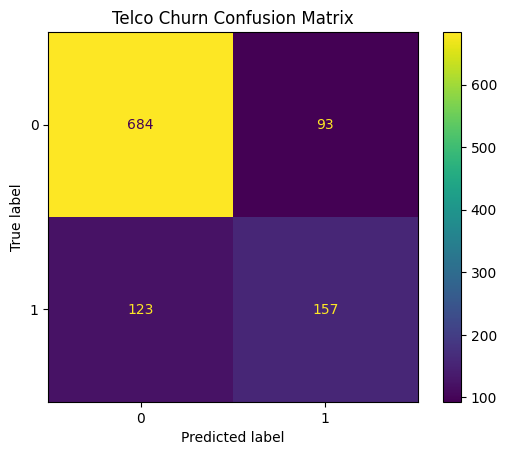

ROC-AUC: 0.8343146718146718


In [19]:
results=regularized_model.evaluate(X_test_scaled,y_test,verbose=0,return_dict=True)
for k,v in results.items():
    print(f"{k}: {v:.4f}")

y_prob=regularized_model.predict(X_test_scaled,verbose=0).ravel()
y_pred=(y_prob>=0.5).astype(int)

print(classification_report(y_test,y_pred,zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.title("Telco Churn Confusion Matrix")
plt.show()
print("ROC-AUC:",roc_auc_score(y_test,y_prob))

## 18. ROC and Precision-Recall Curves
ROC-AUC measures ranking performance across thresholds.
Precision-Recall is especially useful when the positive class is less common.

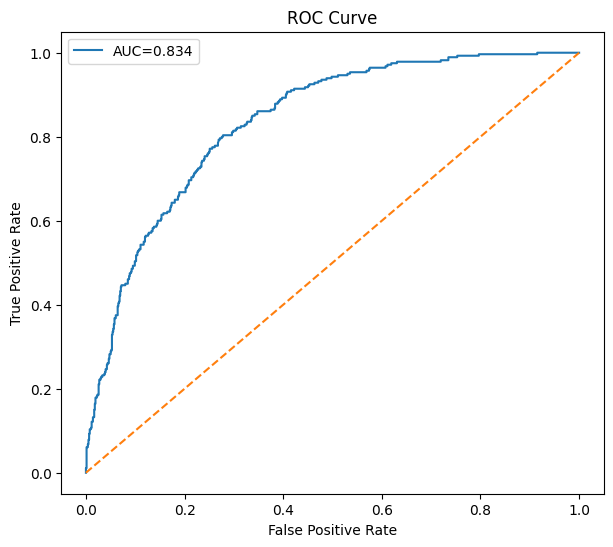

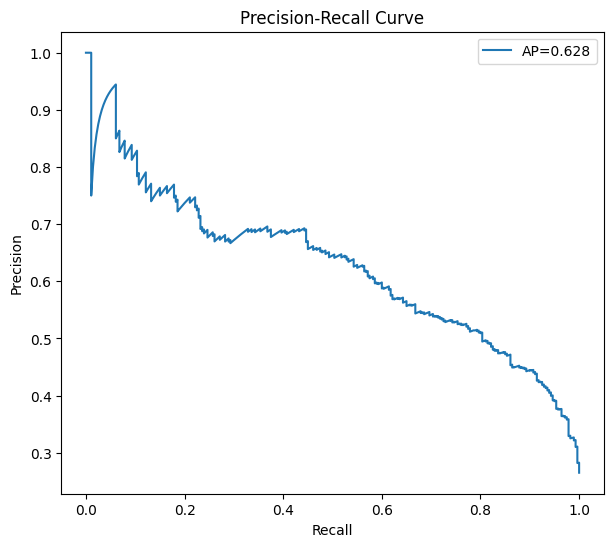

In [20]:
fpr,tpr,_=roc_curve(y_test,y_prob)
auc=roc_auc_score(y_test,y_prob)
plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,label=f'AUC={auc:.3f}')
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend(); plt.show()

precision,recall,_=precision_recall_curve(y_test,y_prob)
ap=average_precision_score(y_test,y_prob)
plt.figure(figsize=(7,6))
plt.plot(recall,precision,label=f'AP={ap:.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve'); plt.legend(); plt.show()

## 19. Threshold Tuning – Business Decision
Default threshold is 0.5.

For customer retention, missing a likely churner may be costly. A lower threshold can increase recall but also increases unnecessary customer contacts.

In [21]:
for threshold in [0.2,0.3,0.4,0.5,0.6,0.7]:
    pred=(y_prob>=threshold).astype(int)
    r=classification_report(y_test,pred,output_dict=True,zero_division=0)
    print(f"Threshold={threshold:.1f} | Precision={r['1']['precision']:.3f} | Recall={r['1']['recall']:.3f} | F1={r['1']['f1-score']:.3f}")

Threshold=0.2 | Precision=0.463 | Recall=0.861 | F1=0.603
Threshold=0.3 | Precision=0.529 | Recall=0.750 | F1=0.620
Threshold=0.4 | Precision=0.565 | Recall=0.650 | F1=0.605
Threshold=0.5 | Precision=0.628 | Recall=0.561 | F1=0.592
Threshold=0.6 | Precision=0.688 | Recall=0.432 | F1=0.531
Threshold=0.7 | Precision=0.680 | Recall=0.250 | F1=0.366


## 20. Save and Load Model
Saving allows the trained neural network to be reused for deployment or inference.

In [22]:
MODEL_PATH="telco_churn_keras_model.keras"
regularized_model.save(MODEL_PATH)
loaded_model=tf.keras.models.load_model(MODEL_PATH)
print("Model saved and loaded successfully.")

Model saved and loaded successfully.


# Final Revision and Next DL Module

### What this notebook taught
Data preprocessing → scaling → neural network training → optimizers → learning rate → regularization → dropout → BatchNorm → early stopping → class imbalance → threshold tuning → evaluation → model persistence.

## Recommended Next Deep Learning Module: Computer Vision with CNN
1. Images as tensors
2. Convolution
3. Filters/kernels
4. Padding and stride
5. Pooling
6. CNN architecture
7. Image augmentation
8. Transfer learning
9. Image classification project

**Next hands-on project recommendation: CNN-based image classification.**